# Introduction to Regression with Neural Networks in TensorFlow

There are many defenitions for a regression problem but in our case, we're going to simplify it: predicting a numerical variable based on some other combination of variables, even shorter... predicting a number.

In [ ]:
#Import TensorFlow
import tensorflow as tf
print(tf.__version__)

2.19.0


# Creating data to view and fit

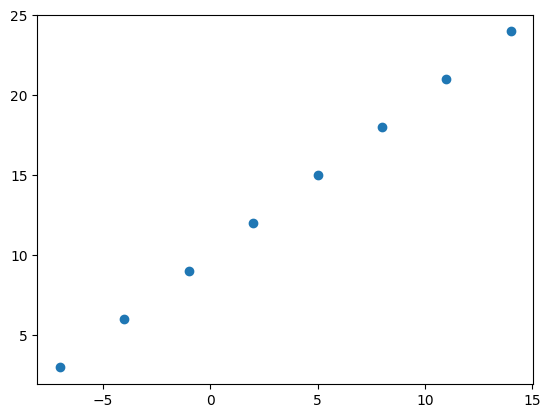

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Create featrues
X = np.array([-7.0 , -4.0 , -1.0 , 2.0 , 5.0 , 8.0 , 11.0 , 14.0])

#Create labels
y = np.array([3.0 , 6.0 , 9.0 , 12.0 , 15.0 , 18.0 , 21.0 , 24.0])

#Visualize it
plt.scatter(X , y);


In [ ]:
y == X+10

array([ True,  True,  True,  True,  True,  True,  True,  True])

# Input and output shapes

In [ ]:
#Create a demo tensor for our housing price prediction problem
housing_info = tf.constant(["bedroom" , "bathroom" , "garage"])
housing_price = tf.constant([939700])
housing_info , housing_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [ ]:
X[0] , y[0]

(np.float64(-7.0), np.float64(3.0))

In [ ]:
X[1] , y[1]

(np.float64(-4.0), np.float64(6.0))

In [ ]:
input_shape = X.shape
output_shape = y.shape
input_shape , output_shape

((8,), (8,))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Create featrues
X = np.array([-7.0 , -4.0 , -1.0 , 2.0 , 5.0 , 8.0 , 11.0 , 14.0])

#Create labels
y = np.array([3.0 , 6.0 , 9.0 , 12.0 , 15.0 , 18.0 , 21.0 , 24.0])

#Turn our NumPy arrays into tensors with dtype32 and reshape X
X = tf.cast(tf.constant(X) , dtype = tf.float32)
y = tf.cast(tf.constant(y) , dtype = tf.float32)
X = tf.expand_dims(X, axis=-1)
X , y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape , output_shape

(TensorShape([1]), TensorShape([]))

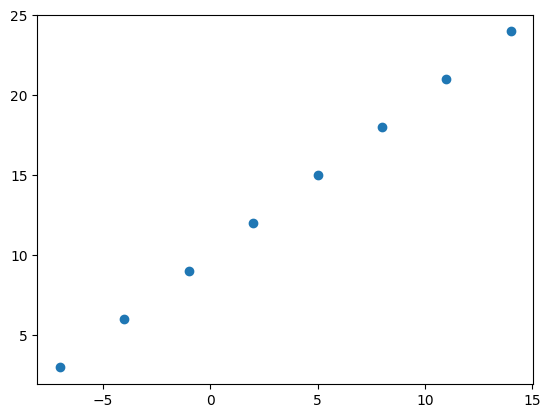

In [ ]:
plt.scatter(X , y)

# Steps in modelling with TensorFlow

1. Creating a model - define the input and output layers, as well as the hidden layers of a deep learning model.
2. Compiling a model - define the loss function(in other words, the function which tells our model how wrong it is) and the optimizer(tells our model how to improve the patterns it's learning)and evaluation metrics(what we can use to interpret the performance of our model).
3. Fitting the model - letting the model try to find patterns between X & y (features and labels).

In [ ]:
#Set random seed
tf.random.set_seed(42)

# 1. create a model using the sequential API
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss = tf.keras.losses.mae, # mae is short for mean absolute error
              optimizer = tf.keras.optimizers.SGD(), # SGD is short for stochastic gradient descent
              metrics=["mae"])

# Fit the model
model.fit(X,y, epochs=5)


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step - loss: 7.7570 - mae: 7.7570
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 7.6245 - mae: 7.6245
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 7.4920 - mae: 7.4920
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 7.4775 - mae: 7.4775
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.4719 - mae: 7.4719


In [ ]:
#Check out X and Y
X , y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
# Try and make a prediction using our model
y_pred = model.predict(tf.constant([[17.0]], dtype=tf.float32))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([[29.724504]], dtype=float32)

In [ ]:
y_pred + 13

array([[42.724503]], dtype=float32)

# Improving our model

We can improve our model,by altering the steps we took to create a model.

1. **Creating a model** - here we might add more layers,increase the number of hidden units(all called neurons)within each of the hidden layers,change the activation function of each of each layer.
2. **Compiling a model** - here we might change the optimization function or perhaps the **learning rate** of the optimization function.
3. **Fitting a model** - here we might fit a model for more **epochs**(leave it training for longer) or on more data(give the model more examples to learn from).

In [ ]:
#Let's rebuild our model

# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile a model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# 3. Fit a model
model.fit(X , y , epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - loss: 9.6911 - mae: 9.6911
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 9.5586 - mae: 9.5586
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 9.4261 - mae: 9.4261
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 9.2936 - mae: 9.2936
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 9.1611 - mae: 9.1611
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 9.0286 - mae: 9.0286
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 8.8961 - mae: 8.8961
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 8.7636 - mae: 8.7636
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 8.6311 - mae: 8.6311
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 8.4986 - mae: 8.4986
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 8.3661 - mae: 8.3661
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 8.2336 - mae: 8.2336
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/st

In [ ]:
#Remind ourselves of the data
X , y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
# Let's see if our model's prediction has improved...
model.predict(tf.constant([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([[30.005552]], dtype=float32)

In [ ]:
#Let's see if we can make another change to improve our model

# 1. create the model (this time with an extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50 , activation=None),
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mae"])

# Fit the model
model.fit(X , y , epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 12.0893 - mae: 12.0893
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 11.3664 - mae: 11.3664
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 10.6313 - mae: 10.6313
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 9.8827 - mae: 9.8827
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 9.1180 - mae: 9.1180
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 8.3340 - mae: 8.3340
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 7.5278 - mae: 7.5278
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 6.8985 - mae: 6.8985
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 6.9984 - mae: 6.9984
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 7.2743 - mae: 7.2743
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 7.4183 - mae: 7.4183
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 7.5303 - mae: 7.5303
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [ ]:
#Let's remind ourselves of the data
X , y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
#Let's try to make a prediction
model.predict(tf.constant([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([[26.657162]], dtype=float32)

# Evaluating a model

In practice , a typical workflow you'll go throught when building neural networks is:

```
Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it...

```

When it comes to evaluation... there are 3 words you should memorize:

>"Visualize,visualize,visualize"

It's a good idea to visualize:
* The data - what data are we working with? What does it look like?
* The model itself - What does our model look like ?
* The training of a model - how does a model perform while it learns?
* The predictions of the model - how do the predictions of a model line up against the ground truth(the original labels)?

In [ ]:
#Make bigger dataset
X = tf.range(-100 , 100 , 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [ ]:
#Make labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

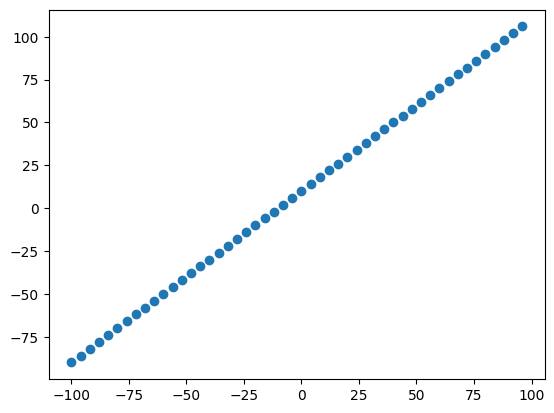

In [ ]:
# visualize the data
import matplotlib.pyplot as plt
plt.scatter(X , y)

#The 3 sets...

* **Training set** - the model learns from this data, which is typically 70-80% of the total data you have available.
* **Validation set** - the model gets tuned on this data, which is typically 10-15% of the data available.
* **Test set** - the model gets evaluated on this data to test what is has learned, this set is typically 10-15% of the total data available.

In [ ]:
#Check the length of how many samples we have
len(X)

50

In [ ]:
# Split the data into train and test sets
x_train = X[:40] # First 40 are training samples (80% of the data)
y_train = y[:40]

x_test = X[40:] # last 10 are testing samples (20% of the data)
y_test = y[40:]

len(x_train) , len(x_test) , len(y_train) , len(y_test)

(40, 10, 40, 10)

# Visualizing the data

Now we've got our data in training and test sets... let's visualize it again!

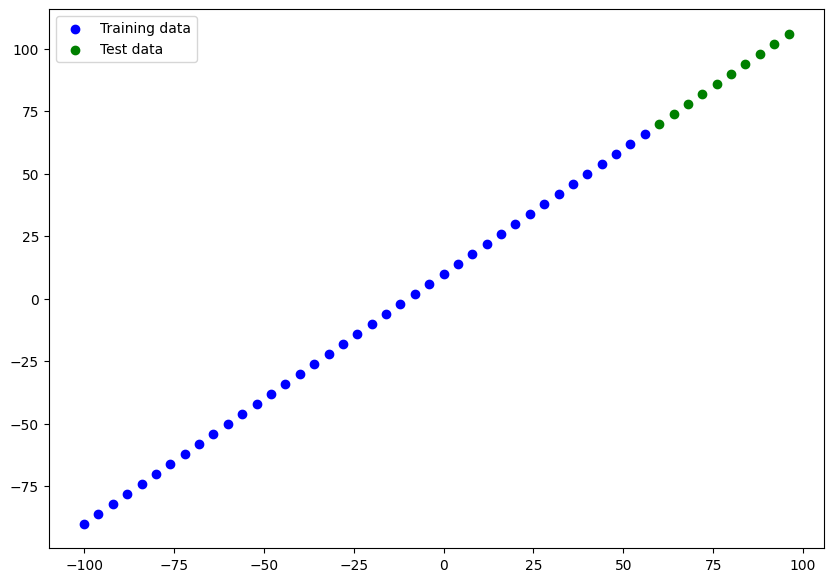

In [ ]:
plt.figure(figsize=(10 , 7))
#plot the training data in blue
plt.scatter(x_train , y_train , c="b" , label="Training data")
# plot the test data in green
plt.scatter(x_test , y_test , c="g" , label="Test data")
#Show a legend
plt.legend();

In [ ]:
#Let's have a look at how to build a neural network for our data

# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile a model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# # 3. Fit a model
# model.fit(x_train , y_train , epochs=100)

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X[0] , y[0]

(<tf.Tensor: shape=(), dtype=int32, numpy=-100>,
 <tf.Tensor: shape=(), dtype=int32, numpy=-90>)

In [ ]:
tf.random.set_seed(42)

# Create a model (same as above)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10 , input_shape=[1] , name="input_layer"),
    tf.keras.layers.Dense(1, name="Output_layer")
] , name="model_1")

#Compile a model (same as above)
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

* Total params - total number of parameters in the model.
* Trainable parameters - these are the parameters(patterns) the model can update as it trains.
* Non-trainable params - these parameters aren't updated during training(this is typical when you bring in already learn patterns or parameters from other models during **transfer learning**).

In [ ]:
#Let's fit our model
model.fit(x_train , y_train , epochs=100 , verbose=0)

In [ ]:
#Get a summary of our model
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

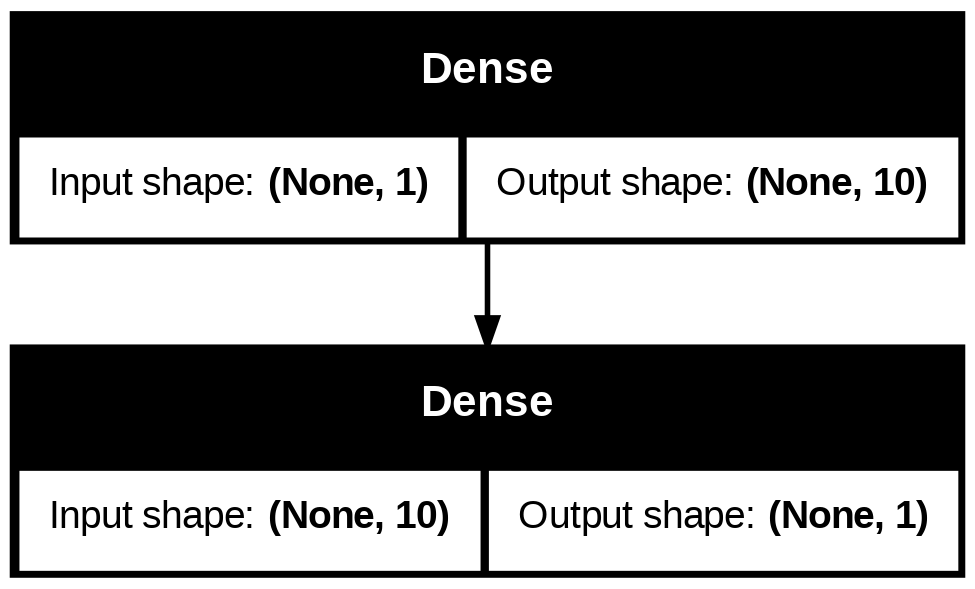

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model = model , show_shapes=True)

# Visualizing our model's predictions

To visualize predictions, it's a good idea to plot them against the ground truth labels.

Often you'll see this in the form of `y_test` or `y_true` versus `y_pred` (ground truth versus your model's predictions).

In [ ]:
#Make some predictions
y_pred = model.predict(x_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


array([[33.82873 ],
       [35.980293],
       [38.131855],
       [40.283413],
       [42.43498 ],
       [44.58654 ],
       [46.738102],
       [48.88966 ],
       [51.041218],
       [53.192783]], dtype=float32)

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

**Note:** if you feel like you you're going to reuse some kind of functionality in the future, it's a good idea to turn it into a function.

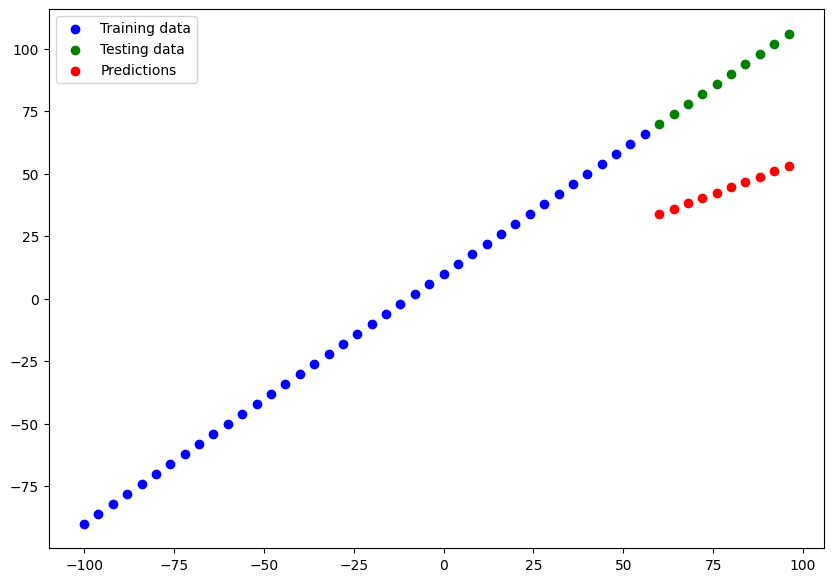

In [ ]:
#Let's create plotting function
def plot_predictions(train_data = x_train,
                     train_labels = y_train,
                     test_data = x_test,
                     test_labels = y_test,
                     predictions = y_pred):
   """
   Plots training data , test data and compares predictions to ground truth labels.
   """
   plt.figure(figsize=(10,7))
   #Plot training data in Blue
   plt.scatter(train_data , train_labels , c="b" , label="Training data")
   #Plot testing data in green
   plt.scatter(test_data , test_labels , c="g" , label = "Testing data")
   #Plot model's predictions in red
   plt.scatter(test_data , predictions , c="r" , label = "Predictions") # Use 'predictions' parameter
   #Set a legend
   plt.legend()

# Call the function to plot the predictions
plot_predictions(train_data = x_train,
                 train_labels = y_train,
                 test_data = x_test,
                 test_labels = y_test,
                 predictions = y_pred)

# Evaluating our model's predictions with regression evaluation metrics

Depending on the problem you're working on,there will be different evaluation metrics to evaluate your model's performance.

Since we're working on a regression, two of the main metrics:
* MAE - mean absolute error,"on average, how wrong is each of my model's predictions"
* MSE - mean square error," square the average error"


In [ ]:
#Evaluate the model on the test set
model.evaluate(x_test , y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 44.4892 - mae: 44.4892


[44.48924255371094, 44.48924255371094]

In [ ]:
y_pred

array([[33.82873 ],
       [35.980293],
       [38.131855],
       [40.283413],
       [42.43498 ],
       [44.58654 ],
       [46.738102],
       [48.88966 ],
       [51.041218],
       [53.192783]], dtype=float32)

In [ ]:
#Calculate the mean absolute error
mae = tf.keras.losses.mae(y_true = y_test,
                                     y_pred = tf.constant(y_pred))
mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([36.17127 , 38.019707, 39.868145, 41.716587, 43.56502 , 45.41346 ,
       47.261898, 49.11034 , 50.958782, 52.807217], dtype=float32)>

In [ ]:
tf.constant(y_pred)

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[33.82873 ],
       [35.980293],
       [38.131855],
       [40.283413],
       [42.43498 ],
       [44.58654 ],
       [46.738102],
       [48.88966 ],
       [51.041218],
       [53.192783]], dtype=float32)>

In [ ]:
tf.squeeze(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([33.82873 , 35.980293, 38.131855, 40.283413, 42.43498 , 44.58654 ,
       46.738102, 48.88966 , 51.041218, 53.192783], dtype=float32)>

In [ ]:
#Recalculate the mean absolute error
mae = tf.keras.losses.mae(y_true = y_test,
                          y_pred = tf.squeeze(y_pred))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=44.48924255371094>

In [ ]:
#Calculate the mean square error
mse = tf.keras.losses.mse(y_true = y_test,
                          y_pred = tf.squeeze(y_pred))
mse

<tf.Tensor: shape=(), dtype=float32, numpy=2007.480712890625>

In [ ]:
#Make some functions to reuse MAE and MSE
def mae(y_true , y_pred):
  return tf.keras.losses.mae(y_true = y_true,
                             y_pred = tf.squeeze(y_pred))

def mse(y_true , y_pred):
  return tf.keras.losses.mse(y_true = y_true,
                             y_pred = tf.squeeze(y_pred))


## Running experiments to improve our model

```
Build a model -> fit it -> evaluate it -> tweak it -> fit it -> evaluate it -> tweak it -> fit it -> evaluate it ...
```

1. Get more data - get more examples for your model to train on (more opportunities to learn patterns or relationships between features and labels).
2. Make your model larger (using a more complex model)-this might come in the form of more layers or more hidden units in each layer.
3. Train for longer - give your model more of a chance to find patterns in the data.

Let's do 3 modelling experiments:

1. `model_1` - same as the original model , 1 layer , trained for 100 epochs.
2. `model_2` - 2 layers , trained for 100 epochs.
3. `model_3` - 2 layers , trained for 500 epochs.

**Build model_1**

In [ ]:
X , y
x_train = tf.cast(tf.constant(x_train) , dtype=tf.float32)
y_train = tf.cast(tf.constant(y_train) , dtype = tf.float32)
x_train = tf.expand_dims(x_train , axis=-1)

In [ ]:
x_train , y_train

(<tf.Tensor: shape=(40, 1), dtype=float32, numpy=
 array([[-100.],
        [ -96.],
        [ -92.],
        [ -88.],
        [ -84.],
        [ -80.],
        [ -76.],
        [ -72.],
        [ -68.],
        [ -64.],
        [ -60.],
        [ -56.],
        [ -52.],
        [ -48.],
        [ -44.],
        [ -40.],
        [ -36.],
        [ -32.],
        [ -28.],
        [ -24.],
        [ -20.],
        [ -16.],
        [ -12.],
        [  -8.],
        [  -4.],
        [   0.],
        [   4.],
        [   8.],
        [  12.],
        [  16.],
        [  20.],
        [  24.],
        [  28.],
        [  32.],
        [  36.],
        [  40.],
        [  44.],
        [  48.],
        [  52.],
        [  56.]], dtype=float32)>,
 <tf.Tensor: shape=(40,), dtype=float32, numpy=
 array([-90., -86., -82., -78., -74., -70., -66., -62., -58., -54., -50.,
        -46., -42., -38., -34., -30., -26., -22., -18., -14., -10.,  -6.,
         -2.,   2.,   6.,  10.,  14.,  18.,  22.,  26., 

In [ ]:
#Set the random seed
tf.random.set_seed(42)

# 1. Create a model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# 2. Compile a model
model_1.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics=["mae"])
# 3. Fit a model
model_1.fit(x_train , y_train , epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 66.4121 - mae: 66.4121 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 31.5702 - mae: 31.5702
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.8687 - mae: 8.8687
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.3374 - mae: 10.3374
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 12.1379 - mae: 12.1379
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 12.5769 - mae: 12.5769
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 8.0333 - mae: 8.0333
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.7432 - mae: 9.7432
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 8.0154 - mae: 8.0154
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9.7316 - mae: 9.7316
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 7.9976 - mae: 7.9976
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.7200 - mae: 9.7200
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


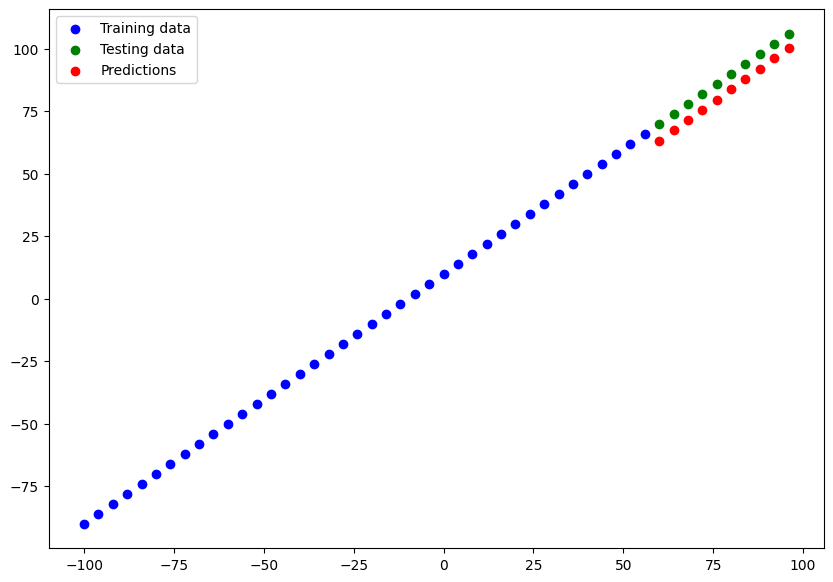

In [ ]:
#Make and plot predictions for model_1
y_preds_1 = model_1.predict(x_test)
plot_predictions(predictions = y_preds_1)

In [ ]:
tf.constant(y_preds_1) , tf.squeeze(y_preds_1)

(<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
 array([[ 63.19827],
        [ 67.31886],
        [ 71.43945],
        [ 75.56005],
        [ 79.68064],
        [ 83.80124],
        [ 87.92183],
        [ 92.04242],
        [ 96.16302],
        [100.28361]], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 63.19827,  67.31886,  71.43945,  75.56005,  79.68064,  83.80124,
         87.92183,  92.04242,  96.16302, 100.28361], dtype=float32)>)

In [ ]:
#Calculate model_1 evaluation metrics
mae_1 = mae(y_test , y_preds_1)
mse_1 = mse(y_test , y_preds_1)
mae_1 , mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=6.259060859680176>,
 <tf.Tensor: shape=(), dtype=float32, numpy=39.29582595825195>)

**Build model_2**

* 2 Dense layers, trained for 100 epochs

In [ ]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["mse"])
# 3. Fit the model
model_2.fit(x_train , y_train , epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 33.4540 - mse: 1531.7883 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 27.5052 - mse: 1029.4885
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 25.1131 - mse: 858.9254
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 15.0879 - mse: 343.8725
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 19.1578 - mse: 490.9367
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 13.2101 - mse: 262.4302
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 15.1214 - mse: 318.5532
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 15.7940 - mse: 338.0425
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 11.7510 - mse: 215.5402 
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 14.7040 - mse: 300.5826
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 15.7187 - mse: 332.9211
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 11.9311 - mse: 215.3368
Epoch 13/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


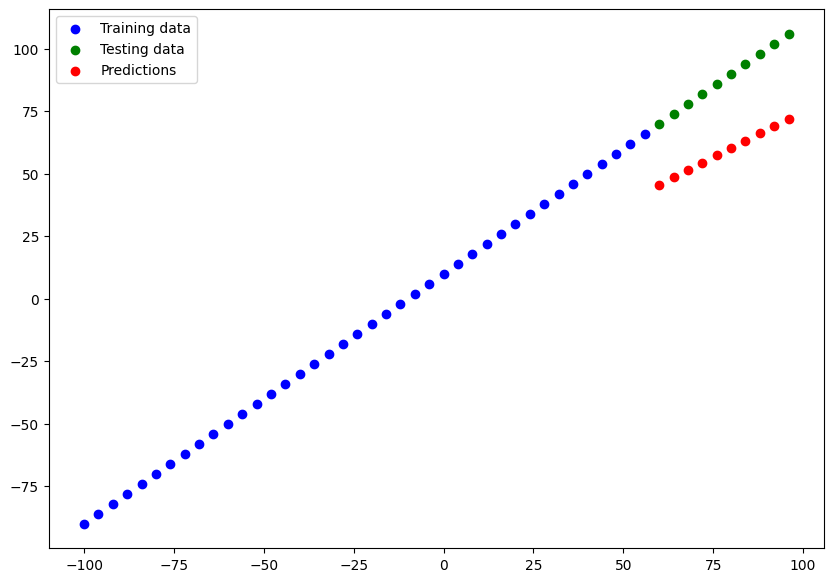

In [ ]:
#Make and plot predictions for model_2
y_preds_2 = model_2.predict(x_test)
plot_predictions(predictions = y_preds_2)

In [ ]:
#Calculate model_2 evaluation metrics
mae_2 = mae(y_test , y_preds_2)
mse_2 = mse(y_test , y_preds_2)

mae_2 , mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=29.127355575561523>,
 <tf.Tensor: shape=(), dtype=float32, numpy=857.79150390625>)

**Build model_3**

* 2 layers, trained for 500 epochs

In [ ]:
#Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["mse"])

# 3. Fit the model
model_3.fit(x_train , y_train , epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 44.7588 - mse: 2778.1399 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 33.9742 - mse: 1598.6448
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 23.9761 - mse: 780.2012
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 19.8290 - mse: 533.3432
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 17.7462 - mse: 429.6000
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 16.8421 - mse: 387.1080
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 16.6499 - mse: 374.9677
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 11.8098 - mse: 219.0214
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 14.7298 - mse: 302.5320
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 15.6704 - mse: 331.6691
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 11.8355 - mse: 214.4754
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 14.8344 - mse: 303.3225
Epoch 13/5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


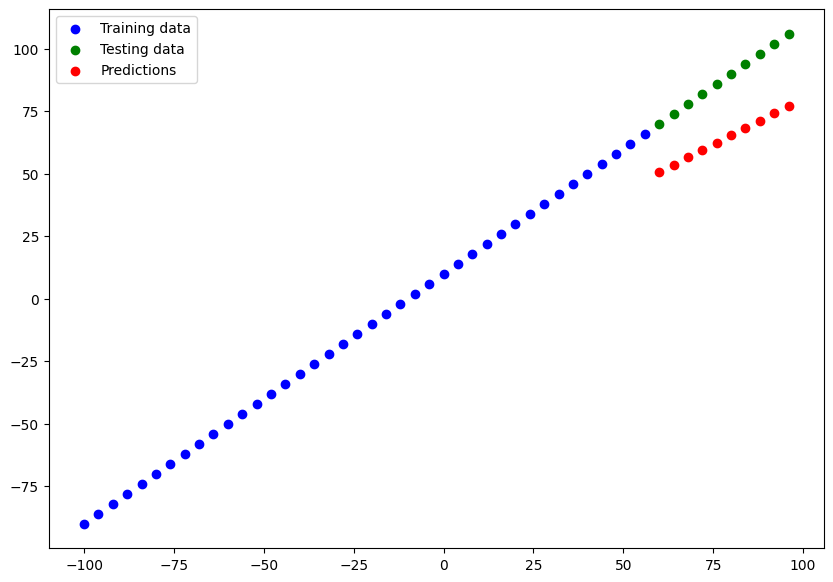

In [ ]:
#Make and plot some predictions
y_preds_3 = model_3.predict(x_test)
plot_predictions(predictions = y_preds_3)

In [ ]:
#Calculate model_3 evaluation metrics
mae_3 = mae(y_test , y_preds_3)
mse_3 = mse(y_test , y_preds_3)

mae_3 , mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=24.07998275756836>,
 <tf.Tensor: shape=(), dtype=float32, numpy=589.1766357421875>)

**Note:** You want to start with small experiments (small models) and make sure they work and then increase their scale when necessary.

# Comparing the results of our experiments

We've run few experiments, let's compare the results

Looks like `model_1` performed the best...

In [ ]:
#Let's compare our model's results using a pandas DataFrame
import pandas as pd

model_results = [["model_1" , mae_1.numpy(), mse_1.numpy()],
                 ["model_2" , mae_2.numpy(), mse_2.numpy()],
                 ["model_3" , mae_3.numpy(), mse_3.numpy()]]
all_results = pd.DataFrame(model_results , columns=["model" , "mae" , "mse"])
all_results


,model,mae,mse
0,model_1,6.259061,39.295826
1,model_2,29.127356,857.791504
2,model_3,24.079983,589.176636


In [ ]:
model_1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

> **Note:** One of your main goals should be to minimize the time between your experiments. The more experiments you do , the more things you'll figure out which don't work and in turn , get closer to figuring out what does work. Remember the machine learning practioner's motto: "experiment , experiment , experiment".

# Tracking your experiments

One really good habit in machine learning modelling is to track the results of your experiments.

And when doing so , it can be tedious if you're running lots of experiments.

Luckily , there are tools to help us:

**Resources:** As you build more models , you'll want to look into using:

* TensorBoard - a component of the TensorFlow library to help track modelling experiments ( we'll see this one later ).
* Weights & Biases - a tool for tracking all of kinds of machine learning experiments (plugs straight into TensorBoard).

# Saving our models

Saving our models allows us to use them outside of Google Colab(or wherever they were trained)such as in a web application or mobile app.

There are two main formats we can save our model's too:
1. The SavedModel format
2. The HDF5 format

In [ ]:
# Save model using the SavedModel format
model_1.save("best_Model_SavedModel_format.keras")

In [ ]:
# Save model using the HDF5 format
model_1.save("best_Model_HDF5_format.h5")

# Loading in a saved model

In [ ]:
#load in the SavedModel format model
loaded_SavedModel_format = tf.keras.models.load_model("best_Model_SavedModel_format.keras")
loaded_SavedModel_format.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
#Compare model_1 predictions with SavedModel format Model predictions
model_1_preds = model_1.predict(x_test)
loaded_SavedModel_format_preds = loaded_SavedModel_format.predict(x_test)
model_1_preds == loaded_SavedModel_format_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [ ]:
mae(y_true = y_test , y_pred = model_1_preds) == mae(y_true = y_test , y_pred = loaded_SavedModel_format_preds)

<tf.Tensor: shape=(), dtype=bool, numpy=True>

In [ ]:
#Load in a model using the .h5 format
loaded_h5_model = tf.keras.models.load_model("best_Model_HDF5_format.h5")
loaded_h5_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
#Check to see if loaded .h5 model predictions match model_1
model_1_preds = model_1.predict(x_test)
loaded_h5_model_preds = loaded_h5_model.predict(x_test)
model_1_preds == loaded_h5_model_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

# A larger example

In [ ]:
# Import required libraries
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Read in the insurance dataset
insurance = pd.read_csv(  )
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
insurance_one_hot = pd.get_dummies(insurance).astype(int)
insurance_one_hot

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,1,0,0,1,0,0,0,1
1,18,33,1,1725,0,1,1,0,0,0,1,0
2,28,33,3,4449,0,1,1,0,0,0,1,0
3,33,22,0,21984,0,1,1,0,0,1,0,0
4,32,28,0,3866,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30,3,10600,0,1,1,0,0,1,0,0
1334,18,31,0,2205,1,0,1,0,1,0,0,0
1335,18,36,0,1629,1,0,1,0,0,0,1,0
1336,21,25,0,2007,1,0,1,0,0,0,0,1


In [ ]:
#Create X & y values (features and labels)
X = insurance_one_hot.drop("charges" , axis=1)
y = insurance_one_hot["charges"]

In [ ]:
# View x
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27,0,1,0,0,1,0,0,0,1
1,18,33,1,0,1,1,0,0,0,1,0
2,28,33,3,0,1,1,0,0,0,1,0
3,33,22,0,0,1,1,0,0,1,0,0
4,32,28,0,0,1,1,0,0,1,0,0


In [ ]:
#View y
y.head()

,charges
0,16884
1,1725
2,4449
3,21984
4,3866


In [ ]:
#Create training and test sets
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(X,
                                                       y,
                                                       test_size=0.2,
                                                       random_state=42)
len(X) , len(x_train) , len(x_test)

(1338, 1070, 268)

In [ ]:
#Build a neural network (Sort of like model_1 above)
tf.random.set_seed(42)

# 1. Create the model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model.compile(loss = tf.keras.losses.mae,
                        optimizer = tf.keras.optimizers.SGD(),
                        metrics = ["mae"])

# 3 . Fit the model
insurance_model.fit(x_train , y_train , epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10012.2031 - mae: 10012.2031
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7627.8145 - mae: 7627.8145
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7990.8774 - mae: 7990.8774
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7292.6367 - mae: 7292.6367 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7160.5259 - mae: 7160.5259 
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7725.2300 - mae: 7725.2300
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7535.9277 - mae: 7535.9277 
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7369.2568 - mae: 7369.2568 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7634.5854 - mae: 7634.5854 
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7715.1934 - mae: 7715.1934 
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7646.3491 - mae: 7646.3491
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3

In [ ]:
#Check the results of the insurance model on the test data
insurance_model.evaluate(x_test , y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8033.1025 - mae: 8033.1025  


[8000.416015625, 8000.416015625]

In [ ]:
y_train.median() , y_train.mean()

(9574.5, np.float64(13345.596261682243))

Right now it looks like our model isn't performing too well... let's try and improve it!

To (try) improve our model, we'll run 2 experiments:
1. Add an extra layer with more hidden units and use the Adam optimizer
2. Same as above but train for longer(200 epochs)
3. (insert your own experiment here)

In [ ]:
#Set the random seed
tf.random.set_seed(42)

# 1. Create the model
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_2.compile(loss = tf.keras.losses.mae,
                          optimizer = tf.keras.optimizers.Adam(),
                          metrics = ["mae"])

# 3. Fit the model
insurance_model_2.fit(x_train , y_train , epochs=100 , verbose=1)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 13260.8281 - mae: 13260.8281
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13106.1758 - mae: 13106.1758
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12788.7656 - mae: 12788.7656
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12167.1523 - mae: 12167.1523
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11109.0654 - mae: 11109.0654
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9694.0264 - mae: 9694.0264
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8297.2891 - mae: 8297.2891
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7519.2056 - mae: 7519.2056
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7385.4087 - mae: 7385.4087
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7357.6685 - mae: 7357.6685
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7336.4502 - mae: 7336.4502
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
#Evaluate the larger model
insurance_model_2.evaluate(x_test , y_test)
insurance_model_2

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4835.0879 - mae: 4835.0879  


<Sequential name=sequential_8, built=True>

In [ ]:
insurance_model.evaluate(x_test , y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8033.1025 - mae: 8033.1025 


[8000.416015625, 8000.416015625]

In [ ]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model (Same as above)
insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

#2. Compile the model
insurance_model_3.compile(loss = tf.keras.losses.mae,
                          optimizer = tf.keras.optimizers.Adam(),
                          metrics = ["mae"])

# 3. Fit the model
history = insurance_model_3.fit(x_train , y_train , epochs=200)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13280.9404 - mae: 13280.9404
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13126.5244 - mae: 13126.5244
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12823.0791 - mae: 12823.0791
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12222.2646 - mae: 12222.2646
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11174.3945 - mae: 11174.3945
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9730.6406 - mae: 9730.6406
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8286.8652 - mae: 8286.8652
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7491.8018 - mae: 7491.8018
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7362.5449 - mae: 7362.5449
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7334.9404 - mae: 7334.9404
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7312.5884 - mae: 7312.5884
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
insurance_model_3.evaluate(x_test , y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3447.6387 - mae: 3447.6387  


[3381.62255859375, 3381.62255859375]

Text(0.5, 0, 'epochs')

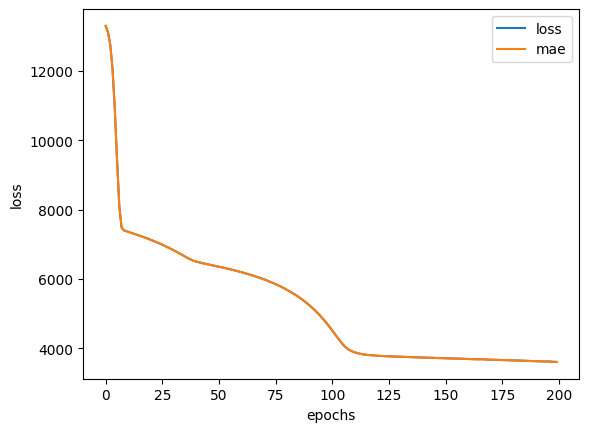

In [ ]:
#Plot history (also known as a loss curve or a training curve)
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

**Question:** How long should you train for?

It depends. Really... it depends on the problem you're working on.However , many people have asked this question before...So TensorFlow has a solution! It's called **EarlyStopping Callback**, which is a TensorFlow component you can add to your model to stop training once it stops improving a certain metric.

# Preprocessing data(normalization and standardization)

In terms of scaling values, neural networks tends to prefer normalization.

<Axes: ylabel='Frequency'>

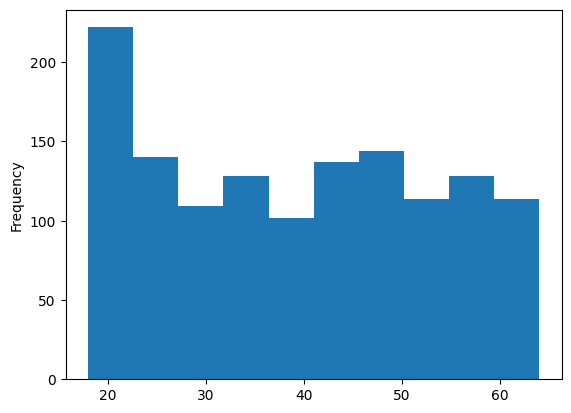

In [ ]:
X["age"].plot(kind="hist")

<Axes: ylabel='Frequency'>

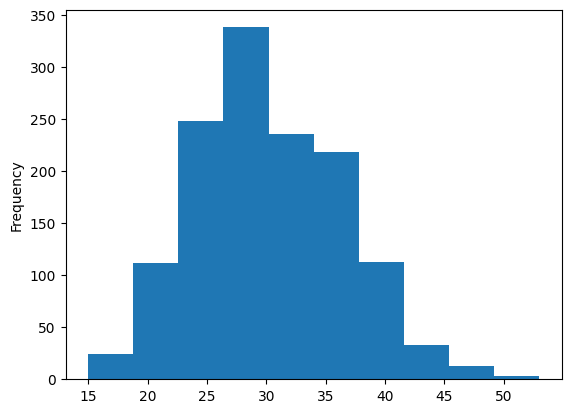

In [ ]:
X["bmi"].plot(kind="hist")

In [ ]:
X["children"].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Read the insurance dataframe
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


To prepare our data, we can borrow a few classes from Scikit-Learn

In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler , OneHotEncoder
from sklearn.model_selection import train_test_split

#Create a column transformer
ct = make_column_transformer(
    (MinMaxScaler(), ["age" , "bmi" , "children"]), # Turn all values in these columns between 0 and 1
    (OneHotEncoder(handle_unknown = "ignore") , ["sex" , "smoker" , "region"])
)

# Create X & y
X = insurance.drop("charges" , axis=1)
y = insurance["charges"]

#Build our train and test sets
x_train , x_test , y_train , y_test = train_test_split(X,
                                                       y,
                                                       test_size=0.2,
                                                       random_state=42)

#Fit the column transformer to our training data
ct.fit(x_train)

#Transform training and test data with normalization (MinMaxScaler) and OnehotEncoder
x_train_normal = ct.transform(x_train)
x_test_normal = ct.transform(x_test)

In [ ]:
#What does our data look like now?
x_train.loc[0]

,0
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest


In [ ]:
x_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [ ]:
x_train.shape , x_train_normal.shape

((1070, 6), (1070, 11))

Beautiful! Our data has been normalized and one hot encoded.Now let's build a neural network model on it and see how it goes.

In [ ]:
#Build a neural network model to fit on our normalized data
tf.random.set_seed(42)

# 1. Create the model
insurance_model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_4.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(),
              metrics = ["mae"])

# 3. Fit the model
insurance_model_4.fit(x_train_normal , y_train , epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 13298.2471 - mae: 13298.2471
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13291.2129 - mae: 13291.2129
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13274.2207 - mae: 13274.2207
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13236.2129 - mae: 13236.2129
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13164.6670 - mae: 13164.6670
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13048.0410 - mae: 13048.0410
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12875.9902 - mae: 12875.9902
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12638.5635 - mae: 12638.5635
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12326.0742 - mae: 12326.0742
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11931.6777 - mae: 11931.6777
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11463.5732 - mae: 11463.5732
Epoch 12/100
34/34 ━━━━━━━━━━━

In [ ]:
# Evaluate our model
insurance_model_4.evaluate(x_test_normal , y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3511.5657 - mae: 3511.5657  


[3426.658447265625, 3426.658447265625]